# ¿Podemos confiar en las explicaciones de los detectores de lenguaje tóxico?
## Comparación de LIME, SHAP e Integrated Gradients con rationales humanas, robustez y auditoría de sesgos léxicos

**Autores:** Haojie Yin y Qian Cheng

**Asignatura:** TÉCNICAS DE INTELIGENCIA ARTIFICIAL EXPLICABLE  

**Máster en Inteligencia Artificial — Facultad de Informática, UCM**  

**Curso:** 2025/26

---

## Resumen

Este proyecto analiza si las explicaciones de los detectores automáticos de lenguaje tóxico son fiables, estables y útiles, más allá de su rendimiento predictivo. Para ello se comparan un modelo clásico basado en **TF-IDF + Regresión Logística** y un **transformer multilingüe compacto** sobre dos datasets públicos: **HateXplain** y **EDOS**.

Se aplican tres métodos XAI —**LIME**, **SHAP** e **Integrated Gradients**— y se evalúan desde cuatro perspectivas: concordancia entre explicadores, alineación con rationales humanas, robustez ante pequeñas perturbaciones y sensibilidad a términos identitarios. Los resultados muestran que el transformer mejora moderadamente el rendimiento, pero sus explicaciones son menos concordantes y más costosas. 
**Palabras clave:** XAI, NLP, toxicidad, LIME, SHAP, Integrated Gradients, HateXplain, EDOS, fairness.


## 1. Introducción

La detección automática de lenguaje tóxico es una tarea cada vez más importante en plataformas digitales, redes sociales, foros y sistemas de moderación de contenido. Su objetivo es identificar mensajes que contienen insultos, acoso, amenazas, discurso de odio o ataques dirigidos a personas o colectivos. Estos sistemas pueden ayudar a priorizar revisiones humanas y a reducir la exposición de los usuarios a contenido dañino, pero también plantean riesgos importantes cuando se aplican de forma automática.

El problema es especialmente delicado porque los errores no tienen todas las mismas consecuencias. Un falso positivo puede etiquetar como tóxico un mensaje legítimo, irónico, reivindicativo o perteneciente a una comunidad concreta, generando censura injusta. Un falso negativo, en cambio, puede dejar pasar abuso real y contribuir a entornos digitales hostiles. A parte es posible que el modelo aprenda sesgos sobre algunas palabras de esta manera pasarlas por alto.

Por este motivo, en este dominio no basta con evaluar si el modelo acierta mediante métricas globales como accuracy o F1. También es necesario estudiar **qué señales utiliza el modelo para tomar sus decisiones**, si esas señales son razonables y si las explicaciones generadas son consistentes. La XAI ofrece herramientas para analizar modelos opacos o parcialmente opacos mediante atribuciones a palabras, comparaciones locales y explicaciones basadas en la importancia de características.

La motivación de este proyecto es evaluar la confianza que podemos depositar en esas explicaciones basandonos en métodos como LIME, SHAP o Integrated Gradients pueden indicar qué palabras empujan una predicción hacia la clase tóxica o no tóxica. Sin embargo, estas explicaciones también pueden ser inestables: dos explicadores pueden destacar palabras distintas para la misma predicción, o una pequeña perturbación del texto puede modificar mucho el ranking de tokens importantes.

Este proyecto presenta un caso de estudio reproducible (seed) sobre detectores de lenguaje tóxico y sexista. La pregunta central no es únicamente **qué modelo clasifica mejor**, sino **hasta qué punto podemos confiar en las explicaciones que acompañan a esa clasificación**. Para responderla, se combinan evaluación predictiva, análisis cualitativo de ejemplos, comparación cuantitativa entre explicadores, robustez ante perturbaciones y una auditoría propia de sensibilidad a términos identitarios.

## 2. Librerías y configuración general

In [1]:
# Instalación de dependencias dentro del notebook
# Ejecutar esta celda solo si el entorno no tiene ya las librerías instaladas.

import sys
import subprocess
instalar = False #Cambiar en caso de que no se tenga las dependencias 
packages = [
    "numpy>=1.24,<2.0",
    "pandas>=2.0,<3.0",
    "matplotlib>=3.7,<4.0",
    "scikit-learn>=1.3,<2.0",
    "scipy>=1.10,<2.0",
    "pyarrow>=14.0",
    "shap>=0.44",
    "lime>=0.2.0.1",
    "torch>=2.1",
    "transformers>=4.46,<5.0",
    "datasets>=2.18,<4.0",
    "accelerate>=0.26",
    "captum>=0.7",
    "jupyter>=1.0",
    "ipykernel>=6.0",
]
if instalar:
    subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    *packages
])

print("Dependencias instaladas correctamente.")

Dependencias instaladas correctamente.


In [2]:

import os

import re
import random
import warnings
from collections import Counter, defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.utils import resample

import shap
from lime.lime_text import LimeTextExplainer

import torch
from torch.utils.data import Dataset

from datasets import load_dataset, Dataset as HFDataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed as hf_set_seed,
)
from captum.attr import IntegratedGradients

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)

In [3]:

@dataclass
class Config:
    seed: int = 99

    # Modelo transformer elegido por viabilidad
    transformer_name: str = "distilbert-base-multilingual-cased"
    max_length: int = 128
    batch_size: int = 16
    eval_batch_size: int = 32
    num_train_epochs: int = 4
    learning_rate: float = 2e-5
    weight_decay: float = 0.01

    # Configuración de TF-IDF + Regresión Logística
    min_df: int = 3
    max_df: float = 0.95
    ngram_range: tuple = (1, 3)
    max_features: int | None = 50000
    logreg_C: float = 4.0

    # Si hay un ordenador poco potente o estas en colab poner ambos en False
    run_transformer_on_edos: bool = True
    run_shap_on_transformer: bool = True

    # Muestreo para explicaciones / auditorías
    explanation_sample_size: int = 60
    robustness_sample_size: int = 40
    fairness_template_repetitions: int = 1

CFG = Config()
print(asdict(CFG))#Configuracion seleccionada

{'seed': 99, 'transformer_name': 'distilbert-base-multilingual-cased', 'max_length': 128, 'batch_size': 16, 'eval_batch_size': 32, 'num_train_epochs': 4, 'learning_rate': 2e-05, 'weight_decay': 0.01, 'min_df': 3, 'max_df': 0.95, 'ngram_range': (1, 3), 'max_features': 50000, 'logreg_C': 4.0, 'run_transformer_on_edos': True, 'run_shap_on_transformer': True, 'explanation_sample_size': 60, 'robustness_sample_size': 40, 'fairness_template_repetitions': 1}


In [4]:
#Mirando dispositivos disponibles
def set_seed(seed: int = 99):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    hf_set_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG.seed)
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():#Macos Metal
    DEVICE = "mps"
else:
    DEVICE = "cpu"

print("DEVICE =", DEVICE)

DEVICE = mps


## 3. Datos

### Origen de los datasets

Se utiliza la combinación **HateXplain + EDOS** porque permite analizar dos dimensiones complementarias del problema:

- **HateXplain**: dataset de discurso dañino con anotaciones de clase y rationales humanas a nivel de token. En este capítulo se transforma la tarea original en una clasificación binaria: `normal` frente a `harmful`, donde `harmful` agrupa `hatespeech` y `offensive`.
- **EDOS (Explainable Detection of Online Sexism)**: dataset de sexismo online. En este capítulo se usa la tarea binaria `sexist` frente a `not_sexist`, manteniendo las etiquetas más finas como contexto descriptivo.

### Variables utilizadas

En ambos datasets la variable principal de entrada es el texto. La variable objetivo es binaria:

- `label = 0`: texto no dañino / no sexista.
- `label = 1`: texto dañino / sexista.

En HateXplain se conservan además:
- `original_label_3`, con la etiqueta original mayoritaria;
- `tokens`, con los tokens del post;
- `rationale_tokens`, con los tokens señalados por anotadores humanos;
- `targets`, con los grupos objetivo anotados cuando están disponibles.

### Preprocesamiento

Solo se normalizan saltos de línea, tabulaciones y espacios repetidos. No se hacen mas preprocesamiento porque puede eliminar pistas que lleven a un texto dañino o con odio.


In [ ]:

#De la pagina oficial de huggingface
HATEXPLAIN_PARQUET_FILES = {
    "train": f"https://huggingface.co/datasets/Hate-speech-CNERG/hatexplain/resolve/3cb70b364e403bd9f7150cfd6f194a12489d5d77/plain_text/hatexplain-train.parquet",
    "validation": f"https://huggingface.co/datasets/Hate-speech-CNERG/hatexplain/resolve/3cb70b364e403bd9f7150cfd6f194a12489d5d77/plain_text/hatexplain-validation.parquet",
    "test": f"https://huggingface.co/datasets/Hate-speech-CNERG/hatexplain/resolve/3cb70b364e403bd9f7150cfd6f194a12489d5d77/plain_text/hatexplain-test.parquet",
}

URL_EDOS = "https://raw.githubusercontent.com/rewire-online/edos/refs/heads/main/data/edos_labelled_aggregated.csv"

LABEL_ID2NAME_HATEXPLAIN = {
    0: "hatespeech",
    1: "normal",
    2: "offensive",
}

In [6]:

def normalize_social_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def _as_list(value):
    if value is None:
        return []
    if isinstance(value, str):
        return [value]
    if isinstance(value, (list, tuple, set, np.ndarray)):
        return list(value)
    return [value]

def annotator_records(annotators) -> list[dict]:
    if isinstance(annotators, dict):
        labels = annotators.get("label", [])
        targets = annotators.get("target", [])
        annotator_ids = annotators.get("annotator_id", [None] * len(labels))
        return [
            {
                "label": lbl,
                "target": _as_list(tgt),
                "annotator_id": ann_id,
            }
            for lbl, tgt, ann_id in zip(labels, targets, annotator_ids)
        ]
    if isinstance(annotators, list):
        records = []
        for ann in annotators:
            if not isinstance(ann, dict):
                continue
            records.append({
                "label": ann.get("label"),
                "target": _as_list(ann.get("target")),
                "annotator_id": ann.get("annotator_id"),
            })
        return records
    return []

def majority_label_from_annotators(annotators) -> str:
    labels = []
    for ann in annotator_records(annotators):
        lbl = ann["label"]
        if lbl is None:
            continue
        if isinstance(lbl, (int, np.integer)):
            lbl = LABEL_ID2NAME_HATEXPLAIN[int(lbl)]
        labels.append(str(lbl))
    if not labels:
        return "normal"
    return Counter(labels).most_common(1)[0][0]

def majority_rationale_tokens(post_tokens, rationales) -> list[str]:
    if rationales is None or len(rationales) == 0:
        return []

    num_tokens = len(post_tokens)
    vote_rows = []
    rationale_items = rationales.get("label", rationales.get("labels", [])) if isinstance(rationales, dict) else rationales

    for rationale in rationale_items:
        if rationale is None:
            continue
        if isinstance(rationale, dict):
            rationale = rationale.get("label", rationale.get("labels", []))
        if not isinstance(rationale, (list, tuple, np.ndarray)):
            continue

        row = np.zeros(num_tokens, dtype=float)
        for idx, value in enumerate(rationale[:num_tokens]):
            try:
                row[idx] = float(value)
            except (TypeError, ValueError):
                row[idx] = 0.0
        vote_rows.append(row)

    if not vote_rows:
        return []

    arr = np.vstack(vote_rows)
    mask = arr.mean(axis=0) >= 0.5
    return [tok for tok, keep in zip(post_tokens, mask) if keep]

def load_hatexplain_binary() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    ds = load_dataset("parquet", data_files=HATEXPLAIN_PARQUET_FILES)

    def convert_split(split_name: str) -> pd.DataFrame:
        rows = []
        for ex in ds[split_name]:
            label_3 = majority_label_from_annotators(ex["annotators"])
            label_bin = 0 if label_3 == "normal" else 1

            targets = []
            for ann in annotator_records(ex["annotators"]):
                targets.extend(ann["target"])
            targets = list(sorted(set(targets)))

            post_tokens = ex["post_tokens"]
            rationale_tokens = majority_rationale_tokens(post_tokens, ex["rationales"])
            text = normalize_social_text(" ".join(post_tokens))

            rows.append({
                "dataset": "hatexplain",
                "split": split_name,
                "id": ex["id"],
                "text": text,
                "label": label_bin,
                "label_name": "harmful" if label_bin == 1 else "non_harmful",
                "original_label_3": label_3,
                "tokens": post_tokens,
                "rationale_tokens": rationale_tokens,
                "targets": targets,
            })
        return pd.DataFrame(rows)

    train_df = convert_split("train")
    val_df = convert_split("validation")
    test_df = convert_split("test")
    return train_df, val_df, test_df

def load_edos_binary() -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = pd.read_csv(URL_EDOS)
    df["text"] = df["text"].astype(str).map(normalize_social_text)
    df["label"] = (df["label_sexist"].str.lower() == "sexist").astype(int)
    df["label_name"] = np.where(df["label"] == 1, "sexist", "not_sexist")
    df["dataset"] = "edos"

    keep_cols = [
        "dataset", "split", "rewire_id", "text", "label", "label_name",
        "label_sexist", "label_category", "label_vector"
    ]
    df = df[keep_cols].rename(columns={"rewire_id": "id"})

    train_df = df[df["split"] == "train"].reset_index(drop=True)
    val_df = df[df["split"] == "dev"].reset_index(drop=True)
    test_df = df[df["split"] == "test"].reset_index(drop=True)
    return train_df, val_df, test_df

In [7]:

hx_train, hx_val, hx_test = load_hatexplain_binary()
edos_train, edos_val, edos_test = load_edos_binary()

print("Entrenamiento || Validacion || Test")
print("HateXplain:", len(hx_train), len(hx_val), len(hx_test))
print("EDOS:", len(edos_train), len(edos_val), len(edos_test))

Entrenamiento || Validacion || Test
HateXplain: 15383 1922 1924
EDOS: 14000 2000 4000


## 4. Mostramos los datos

In [8]:
# Resumen básico de HateXplain
hx_frame = pd.concat([hx_train, hx_val, hx_test], ignore_index=True)

hx_overview = {
    "dataset": "HateXplain",
    "train": len(hx_train),
    "val": len(hx_val),
    "test": len(hx_test),
    "total": len(hx_frame),
    "positive_rate_total": hx_frame["label"].mean(),
    "avg_length_chars": hx_frame["text"].str.len().mean(),
    "avg_length_words": hx_frame["text"].str.split().map(len).mean(),
}

# Resumen básico de EDOS
edos_frame = pd.concat([edos_train, edos_val, edos_test], ignore_index=True)

edos_overview = {
    "dataset": "EDOS",
    "train": len(edos_train),
    "val": len(edos_val),
    "test": len(edos_test),
    "total": len(edos_frame),
    "positive_rate_total": edos_frame["label"].mean(),
    "avg_length_chars": edos_frame["text"].str.len().mean(),
    "avg_length_words": edos_frame["text"].str.split().map(len).mean(),
}

# Tabla comparativa final
overview_df = pd.DataFrame([hx_overview, edos_overview])

overview_df

,dataset,train,val,test,total,positive_rate_total,avg_length_chars,avg_length_words
0,HateXplain,15383,1922,1924,19229,0.593635,126.380363,23.43242
1,EDOS,14000,2000,4000,20000,0.242700,126.996200,23.30960


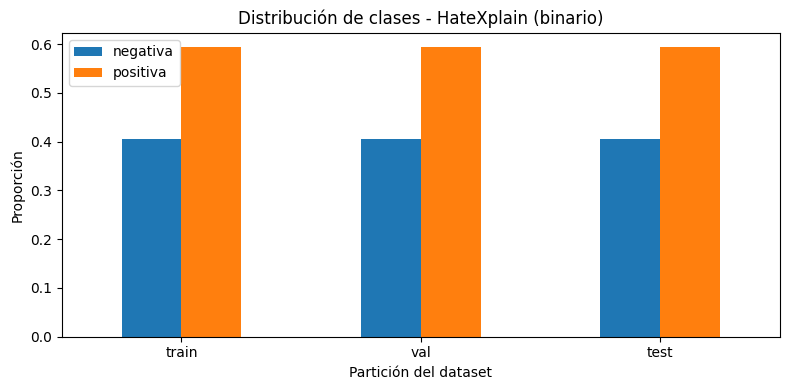

In [9]:
# Distribución de clases - HateXplain
fig, ax = plt.subplots(figsize=(8, 4))

hx_dist = pd.DataFrame({
    "train": hx_train["label"].value_counts(normalize=True).sort_index(),
    "val": hx_val["label"].value_counts(normalize=True).sort_index(),
    "test": hx_test["label"].value_counts(normalize=True).sort_index(),
}).T

hx_dist.columns = ["negativa", "positiva"]

hx_dist.plot(kind="bar", ax=ax)

ax.set_title("Distribución de clases - HateXplain (binario)")
ax.set_ylabel("Proporción")
ax.set_xlabel("Partición del dataset")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

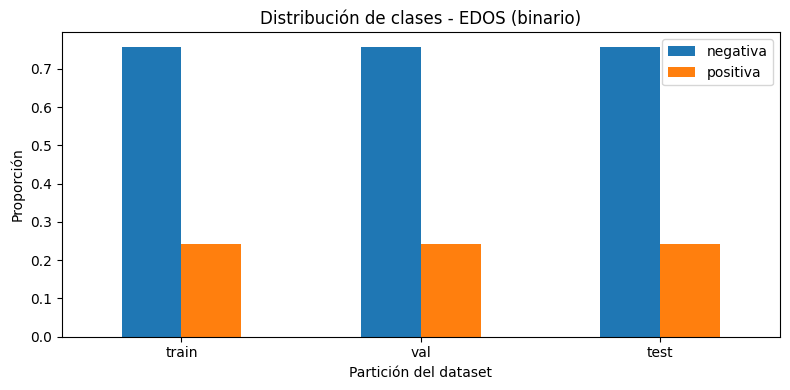

In [10]:
# Distribución de clases - EDOS
fig, ax = plt.subplots(figsize=(8, 4))

edos_dist = pd.DataFrame({
    "train": edos_train["label"].value_counts(normalize=True).sort_index(),
    "val": edos_val["label"].value_counts(normalize=True).sort_index(),
    "test": edos_test["label"].value_counts(normalize=True).sort_index(),
}).T

edos_dist.columns = ["negativa", "positiva"]

edos_dist.plot(kind="bar", ax=ax)

ax.set_title("Distribución de clases - EDOS (binario)")
ax.set_ylabel("Proporción")
ax.set_xlabel("Partición del dataset")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
print("Ejemplos HateXplain:")
display(hx_train[["text", "original_label_3", "rationale_tokens", "targets"]].head(8))

print("\nEjemplos EDOS:")
display(edos_train[["text", "label_sexist", "label_category", "label_vector"]].head(8))

Ejemplos HateXplain:


,text,original_label_3,rationale_tokens,targets
0,u really think i would not have been raped by ...,offensive,"[raped, feral, hindu, muslim, neo, nazi, would...","[Hindu, Islam, Other]"
1,the uk has threatened to return radioactive wa...,offensive,"[paki, migrants]","[Indian, Islam, Minority, Refugee]"
2,if english is not imposition then hindi is als...,offensive,"[chutiya, retards, stophindiimposition]","[Hindu, Other]"
3,no liberal congratulated hindu refugees post c...,offensive,"[hate, hindus]",[Hindu]
4,he said bro even your texts sound redneck what...,offensive,[redneck],"[Caucasian, Economic]"
5,i live and work with many legal mexican immigr...,normal,[],"[Hispanic, Refugee]"
6,in britain the prime minister a childless woma...,hatespeech,"[childless, woman, moslem, invader, lesbian, f...","[Disability, Homosexual, Islam, Refugee, Women]"
7,<user> <user> there shd be a film called no hi...,normal,[],"[Arab, Hindu, Islam]"



Ejemplos EDOS:


,text,label_sexist,label_category,label_vector
0,"Then, she's a keeper. 😉",not sexist,none,none
1,This is like the Metallica video where the poo...,not sexist,none,none
2,woman?,not sexist,none,none
3,Unlicensed day care worker reportedly tells co...,not sexist,none,none
4,[USER] Leg day is easy. Hot girls who wear min...,sexist,3. animosity,3.3 backhanded gendered compliments
5,I don't know if you should avoid this one or e...,not sexist,none,none
6,I get a new pussy every other week or whenever...,sexist,2. derogation,2.3 dehumanising attacks & overt sexual object...
7,Release that shit,not sexist,none,none


## 5. Modelos

1. **TF-IDF + Regresión Logística**
   - Representa cada texto mediante pesos TF-IDF.
   - Es rápido, reproducible y permite inspección directa de coeficientes.
   - Sirve como línea base fuerte para texto, especialmente cuando la toxicidad se expresa mediante vocabulario explícito.
   - Permite aplicar SHAP de forma eficiente con LinearExplainer.

2. **Transformer multilingüe compacto: `distilbert-base-multilingual-cased`**
   - Se ajusta por fine-tuning a HateXplain y EDOS.
   - Puede capturar más contexto que una bolsa de palabras.
   - Es más costoso de entrenar y explicar.
   - Se analiza con LIME e Integrated Gradients.

Buscamos un estudiar un equilibrio entre **rendimiento, transparencia, coste de explicación y estabilidad**.


In [12]:

def build_logreg_pipeline() -> Pipeline:
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=True,
            min_df=CFG.min_df,
            max_df=CFG.max_df,
            ngram_range=CFG.ngram_range,
            max_features=CFG.max_features,
            sublinear_tf=True,
        )),
        ("clf", LogisticRegression(
            max_iter=3000,
            C=CFG.logreg_C,
            class_weight="balanced",
            solver="liblinear",
            random_state=CFG.seed,
        ))
    ])

def compute_binary_metrics(y_true, prob_pos, threshold=0.5) -> dict:
    y_pred = (prob_pos >= threshold).astype(int)
    pr, rc, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    acc = accuracy_score(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, prob_pos)
    except Exception:
        auc = np.nan
    return {
        "accuracy": acc,
        "precision_pos": pr,
        "recall_pos": rc,
        "f1_pos": f1,
        "macro_f1": macro_f1,
        "roc_auc": auc,
    }

def evaluate_pipeline(model: Pipeline, df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    prob_pos = model.predict_proba(df["text"])[:, 1]
    metrics = compute_binary_metrics(df["label"].values, prob_pos)
    preds = (prob_pos >= 0.5).astype(int)
    out_df = df.copy()
    out_df["prob_pos"] = prob_pos
    out_df["pred"] = preds
    return out_df, metrics

def plot_confmat(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    plt.tight_layout()
    plt.show()

In [13]:

logreg_models = {}
logreg_eval = {}
metrics_rows = []

for dataset_name, train_df, val_df, test_df in [
    ("hatexplain", hx_train, hx_val, hx_test),
    ("edos", edos_train, edos_val, edos_test),
]:
    model = build_logreg_pipeline()
    model.fit(train_df["text"], train_df["label"])
    logreg_models[dataset_name] = model

    test_pred_df, test_metrics = evaluate_pipeline(model, test_df)
    test_metrics["dataset"] = dataset_name
    test_metrics["model"] = "tfidf_logreg"
    metrics_rows.append(test_metrics)

    logreg_eval[dataset_name] = {
        "test_df": test_pred_df,
        "metrics": test_metrics,
    }

metrics_logreg_df = pd.DataFrame(metrics_rows).sort_values(["dataset", "model"])
metrics_logreg_df

,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,roc_auc,dataset,model
1,0.813000,0.608187,0.643299,0.625251,0.750333,0.845958,edos,tfidf_logreg
0,0.769751,0.820937,0.782837,0.801434,0.763735,0.837377,hatexplain,tfidf_logreg



=== HATEXPLAIN | TF-IDF + Regresión Logística ===


,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,roc_auc,dataset,model
0,0.769751,0.820937,0.782837,0.801434,0.763735,0.837377,hatexplain,tfidf_logreg


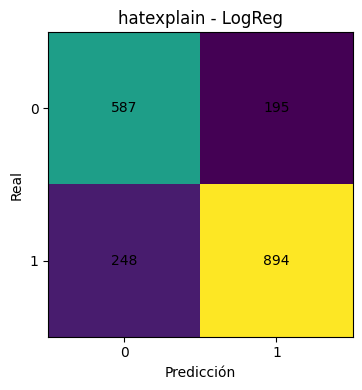


=== EDOS | TF-IDF + Regresión Logística ===


,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,roc_auc,dataset,model
0,0.813,0.608187,0.643299,0.625251,0.750333,0.845958,edos,tfidf_logreg


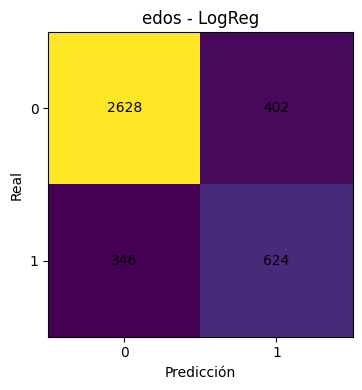

In [14]:

for dataset_name, bundle in logreg_eval.items():
    print(f"\n=== {dataset_name.upper()} | TF-IDF + Regresión Logística ===")
    display(pd.DataFrame([bundle["metrics"]]))
    plot_confmat(bundle["test_df"]["label"], bundle["test_df"]["pred"], f"{dataset_name} - LogReg")

### Preparación del transformer


In [15]:

def df_to_hf_dataset(df: pd.DataFrame) -> HFDataset:
    cols = ["text", "label"]
    return HFDataset.from_pandas(df[cols], preserve_index=False)

tokenizer=AutoTokenizer.from_pretrained(CFG.transformer_name)

def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=CFG.max_length,
    )

def build_hf_splits(train_df, val_df, test_df):
    train_ds = df_to_hf_dataset(train_df)
    val_ds = df_to_hf_dataset(val_df)
    test_ds = df_to_hf_dataset(test_df)

    train_ds = train_ds.map(tokenize_batch, batched=True)
    val_ds = val_ds.map(tokenize_batch, batched=True)
    test_ds = test_ds.map(tokenize_batch, batched=True)
    return train_ds, val_ds, test_ds

def compute_metrics_trainer(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    return compute_binary_metrics(labels, probs)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:

def train_transformer_for_dataset(train_df, val_df, test_df, run_name: str):
    train_ds, val_ds, test_ds = build_hf_splits(train_df, val_df, test_df)

    modelo = AutoModelForSequenceClassification.from_pretrained(
        CFG.transformer_name,
        num_labels=2
    )

    args = TrainingArguments(
        output_dir=f"./outputs/{run_name}",
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="epoch",
        learning_rate=CFG.learning_rate,
        per_device_train_batch_size=CFG.batch_size,
        per_device_eval_batch_size=CFG.eval_batch_size,
        num_train_epochs=CFG.num_train_epochs,
        weight_decay=CFG.weight_decay,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none",
        seed=CFG.seed,
    )

    trainer = Trainer(
        model=modelo,
        args=args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics_trainer,
    )

    trainer.train()

    # Evaluación sobre test
    preds = trainer.predict(test_ds)
    probs = torch.softmax(torch.tensor(preds.predictions), dim=-1).numpy()[:, 1]
    test_metrics = compute_binary_metrics(test_df["label"].values, probs)
    test_pred_df = test_df.copy()
    test_pred_df["prob_pos"] = probs
    test_pred_df["pred"] = (probs >= 0.5).astype(int)

    return trainer, test_pred_df, test_metrics

In [17]:

transformer_models = {}
transformer_eval = {}
transformer_metrics_rows = []

# HateXplain
trainer_hx, hx_test_pred_bert, hx_test_metrics_bert = train_transformer_for_dataset(
    hx_train, hx_val, hx_test, run_name="hatexplain_distilmbert_ep4"
)
hx_test_metrics_bert["dataset"] = "hatexplain"
hx_test_metrics_bert["model"] = "distilmbert"
transformer_models["hatexplain"] = trainer_hx
transformer_eval["hatexplain"] = {"test_df": hx_test_pred_bert, "metrics": hx_test_metrics_bert}
transformer_metrics_rows.append(hx_test_metrics_bert)

# EDOS 
if CFG.run_transformer_on_edos:
    trainer_edos, edos_test_pred_bert, edos_test_metrics_bert = train_transformer_for_dataset(
        edos_train, edos_val, edos_test, run_name="edos_distilmbert"
    )
    edos_test_metrics_bert["dataset"] = "edos"
    edos_test_metrics_bert["model"] = "distilmbert"
    transformer_models["edos"] = trainer_edos
    transformer_eval["edos"] = {"test_df": edos_test_pred_bert, "metrics": edos_test_metrics_bert}
    transformer_metrics_rows.append(edos_test_metrics_bert)

metrics_transformer_df = pd.DataFrame(transformer_metrics_rows)
metrics_transformer_df

Map:   0%|          | 0/15383 [00:00<?, ? examples/s]

Map:   0%|          | 0/1922 [00:00<?, ? examples/s]

Map:   0%|          | 0/1924 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Pos,Recall Pos,F1 Pos,Macro F1,Roc Auc
1,0.528300,0.529039,0.744017,0.744906,0.865031,0.800487,0.721724,0.835081
2,0.418800,0.492875,0.772633,0.815978,0.796670,0.806208,0.765596,0.849714
3,0.326800,0.536302,0.770031,0.803649,0.810692,0.807155,0.761181,0.851912
4,0.243500,0.661943,0.761186,0.788983,0.815951,0.802240,0.750431,0.847113


...

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Pos,Recall Pos,F1 Pos,Macro F1,Roc Auc
1,0.424700,0.364639,0.846000,0.837121,0.454733,0.589333,0.747282,0.868667
2,0.311800,0.341383,0.855000,0.757895,0.592593,0.665127,0.786297,0.886269
3,0.221800,0.448775,0.853500,0.776504,0.557613,0.649102,0.778263,0.872761
4,0.159500,0.583274,0.849000,0.708145,0.644033,0.674569,0.788131,0.868397


,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,roc_auc,dataset,model
0,0.776507,0.815603,0.805604,0.810573,0.769038,0.861772,hatexplain,distilmbert
1,0.844750,0.681582,0.675258,0.678405,0.788041,0.876028,edos,distilmbert


In [18]:

all_metrics_df = pd.concat(
    [metrics_logreg_df, metrics_transformer_df],
    ignore_index=True
).sort_values(["dataset", "model"])
all_metrics_df

,accuracy,precision_pos,recall_pos,f1_pos,macro_f1,roc_auc,dataset,model
3,0.844750,0.681582,0.675258,0.678405,0.788041,0.876028,edos,distilmbert
0,0.813000,0.608187,0.643299,0.625251,0.750333,0.845958,edos,tfidf_logreg
2,0.776507,0.815603,0.805604,0.810573,0.769038,0.861772,hatexplain,distilmbert
1,0.769751,0.820937,0.782837,0.801434,0.763735,0.837377,hatexplain,tfidf_logreg


### Interpretación de las métricas predictivas

El transformer mejora el resultado de HateXplain, especialmente en recall y F1 de la clase positiva, pero el margen de mejora en macro-F1 es moderado.

El modelo clásico con su estructura lineal permite comprobar de forma directa si LIME y SHAP están contando una historia coherente con los pesos internos del clasificador.


## 6. Explicaciones: LIME, SHAP e Integrated Gradients

Esta sección aplica tres familias de explicadores con alcances distintos.

- **LIME** genera perturbaciones locales del texto y entrena un modelo interpretable alrededor de una predicción concreta. Es post-hoc, local y agnóstico al modelo.
- **SHAP** estima contribuciones de características inspiradas en valores de Shapley.
- **Integrated Gradients** atribuye la predicción de una red neuronal a sus entradas acumulando gradientes desde una línea base hasta el texto real, realmente adecuado para transformers

Aplicaciones:
- LIME se usa tanto en el modelo clásico como en el transformer.
- SHAP se aplica sobre el modelo lineal, donde es eficiente y fácil de comparar con los coeficientes.
- Integrated Gradients se utiliza como explicador principal del transformer.

In [19]:

CLASS_NAMES = ["negativo", "positivo"]

def get_label_names(dataset_name: str):
    if dataset_name == "hatexplain":
        return ["non_harmful", "harmful"]
    if dataset_name == "edos":
        return ["not_sexist", "sexist"]
    return CLASS_NAMES

def predict_proba_logreg(dataset_name: str, texts: list[str]) -> np.ndarray:
    model = logreg_models[dataset_name]
    return model.predict_proba(texts)

def predict_proba_transformer(trainer: Trainer, texts: list[str], batch_size: int = 16) -> np.ndarray:
    model = trainer.model.to(DEVICE)
    model.eval()
    probs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=CFG.max_length,
            return_tensors="pt",
        )
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            batch_probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()
        probs.append(batch_probs)
    return np.vstack(probs)

def explain_with_lime(text: str, predict_fn, class_names, num_features: int = 10, positive_class: int = 1):
    explainer = LimeTextExplainer(class_names=class_names)
    exp = explainer.explain_instance(
        text_instance=text,
        classifier_fn=predict_fn,
        num_features=num_features,
        labels=(positive_class,),
    )
    pairs = exp.as_list(label=positive_class)
    return pairs, exp

In [20]:

def local_linear_contributions(text: str, pipeline: Pipeline, positive_class: int = 1, top_k: int = 10):
    vectorizer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]

    X = vectorizer.transform([text])
    feature_names = np.array(vectorizer.get_feature_names_out())

    # Para clasificación binaria, sklearn almacena una única fila de coeficientes
    coef = clf.coef_[0]
    contrib = X.toarray()[0] * coef

    nz = np.nonzero(X.toarray()[0])[0]
    pairs = [(feature_names[i], float(contrib[i])) for i in nz]
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:top_k]
    return pairs

def fit_shap_linear_explainer(pipeline: Pipeline, background_texts: list[str], max_background: int = 200):
    vectorizer = pipeline.named_steps["tfidf"]
    clf = pipeline.named_steps["clf"]
    bg = background_texts[:max_background]
    X_bg = vectorizer.transform(bg)
    explainer = shap.LinearExplainer(clf, X_bg)
    return explainer

def explain_with_shap_linear(text: str, pipeline: Pipeline, shap_explainer, top_k: int = 10):
    vectorizer = pipeline.named_steps["tfidf"]
    X = vectorizer.transform([text])
    feature_names = np.array(vectorizer.get_feature_names_out())

    shap_values = shap_explainer(X)
    values = np.array(shap_values.values)
    if values.ndim == 3:
        # formato [n_samples, n_features, n_classes]
        values = values[0, :, 1]
    elif values.ndim == 2:
        values = values[0]
    else:
        values = np.ravel(values)

    x_row = X.toarray()[0]
    nz = np.nonzero(x_row)[0]
    pairs = [(feature_names[i], float(values[i])) for i in nz]
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:top_k]
    return pairs

In [21]:

shap_explainers_logreg = {}
for dataset_name in ["hatexplain", "edos"]:
    model = logreg_models[dataset_name]
    background_texts = (
        hx_train["text"].tolist() if dataset_name == "hatexplain"
        else edos_train["text"].tolist()
    )
    shap_explainers_logreg[dataset_name] = fit_shap_linear_explainer(
        model,
        background_texts=background_texts,
        max_background=200
    )

In [22]:

SPECIAL_TOKENS = set(tokenizer.all_special_tokens)

def merge_wordpieces(tokens, scores):
    merged_tokens = []
    merged_scores = []
    for tok, score in zip(tokens, scores):
        if tok in SPECIAL_TOKENS:
            continue
        if tok.startswith("##") and merged_tokens:
            merged_tokens[-1] += tok[2:]
            merged_scores[-1] += float(score)
        else:
            merged_tokens.append(tok)
            merged_scores.append(float(score))
    return list(zip(merged_tokens, merged_scores))

def explain_with_integrated_gradients(text: str, trainer: Trainer, target_label: int | None = None, n_steps: int = 50):
    model = trainer.model.to(DEVICE)
    model.eval()

    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=CFG.max_length,
    )
    input_ids = enc["input_ids"].to(DEVICE)
    attention_mask = enc["attention_mask"].to(DEVICE)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
        pred_label = int(logits.argmax(dim=-1).item())

    if target_label is None:
        target_label = pred_label

    embedding_layer = model.get_input_embeddings()
    input_embeds = embedding_layer(input_ids)

    pad_token_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    baseline_ids = torch.full_like(input_ids, pad_token_id)
    baseline_embeds = embedding_layer(baseline_ids)

    def forward_func(inputs_embeds, attention_mask):
        outputs = model(inputs_embeds=inputs_embeds, attention_mask=attention_mask).logits
        probs = torch.softmax(outputs, dim=-1)
        return probs[:, target_label]

    ig = IntegratedGradients(forward_func)
    attributions, delta = ig.attribute(
        inputs=input_embeds,
        baselines=baseline_embeds,
        additional_forward_args=(attention_mask,),
        n_steps=n_steps,
        return_convergence_delta=True,
    )

    token_scores = attributions.sum(dim=-1).squeeze(0).detach().cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0))
    merged = merge_wordpieces(tokens, token_scores)
    merged = sorted(merged, key=lambda x: abs(x[1]), reverse=True)
    return merged, pred_label, float(delta.detach().cpu().numpy().mean())

## 7. Ejemplos cualitativos de explicaciones

En esta sección se muestran ejemplos locales de explicación con una representación visual. Las barras rojas indican contribuciones hacia la clase `harmful`, mientras que las barras azules indican contribuciones hacia `non_harmful`, esto permite comparar de un vistazo qué tokens o n-gramas considera relevante cada explicador.


In [23]:
def choose_balanced_examples(df: pd.DataFrame, n_per_class: int = 2, seed: int = 99):
    parts = []
    for label in sorted(df["label"].unique()):
        sub = df[df["label"] == label]
        k = min(n_per_class, len(sub))
        parts.append(sub.sample(k, random_state=seed))
    return pd.concat(parts).reset_index(drop=True)


def prepare_pairs_for_plot(pairs, top_k: int = 8):
    clean = []
    for token, score in pairs:
        token = str(token).strip()
        if token:
            clean.append((token, float(score)))

    clean = sorted(clean, key=lambda item: abs(item[1]), reverse=True)[:top_k]
    return pd.DataFrame(clean, columns=["token", "contribucion"]).sort_values("contribucion")


def plot_local_explanation_grid(text: str, explanations: dict[str, list[tuple[str, float]]], title: str, top_k: int = 8):
    import textwrap
    n_methods = len(explanations)
    fig, axes = plt.subplots(1, n_methods, figsize=(5.4 * n_methods, 4.8), sharex=False)
    if n_methods == 1:
        axes = [axes]

    for ax, (method_name, pairs) in zip(axes, explanations.items()):
        df_plot = prepare_pairs_for_plot(pairs, top_k=top_k)
        colors = ["tab:red" if value > 0 else "tab:blue" for value in df_plot["contribucion"]]
        ax.barh(df_plot["token"], df_plot["contribucion"], color=colors)
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(method_name)
        ax.set_xlabel("Contribución local")
        ax.grid(axis="x", alpha=0.25)

    wrapped_text = "\n".join(textwrap.wrap(text, width=120))
    fig.suptitle(title, fontsize=13, y=1.02)
    fig.text(0.01, -0.03, f"Texto: {wrapped_text}", ha="left", va="top", fontsize=9)
    fig.tight_layout()
    plt.show()


hx_examples = choose_balanced_examples(hx_test, n_per_class=2, seed=CFG.seed)
hx_examples[["text", "label", "rationale_tokens"]]


,text,label,rationale_tokens
0,i guess i get raped a lot,0,[]
1,look all american good solid nw european desce...,0,[]
2,who were the utter fuckwits that thought nazi ...,1,"[gas, the, kikes]"
3,i m glad ds is back on dailystormer top and no...,1,[kike]


Ejemplo visualizado (modelo lineal): i m glad ds is back on dailystormer top and no kike will ever hold our movement down
Rationale humana: ['kike']
Probabilidad harmful: 0.841
LIME: [('kike', 0.5266413215102284), ('hold', -0.05198333256422678), ('and', -0.050221242750517994), ('ever', -0.0401347376173266), ('movement', -0.03357322103215638), ('back', -0.031601028459210166), ('our', 0.02922013191963184), ('glad', 0.02899405459307543)]
SHAP: [('kike', 2.122270129290098), ('hold', -0.24251194485798594), ('and no', -0.20397441733744745), ('glad', 0.18105936660549424), ('our', 0.1596931597730973), ('movement', -0.13732914751606343), ('back on', -0.13048299462292198), ('ds', 0.12598237331667392)]
Coef*x: [('kike', 2.179288632758515), ('hold', -0.24251194485798594), ('and no', -0.20397441733744745), ('glad', 0.18105936660549424), ('our', 0.16205806130850947), ('movement', -0.13857582949499467), ('back on', -0.13048299462292198), ('ds', 0.12598237331667392)]


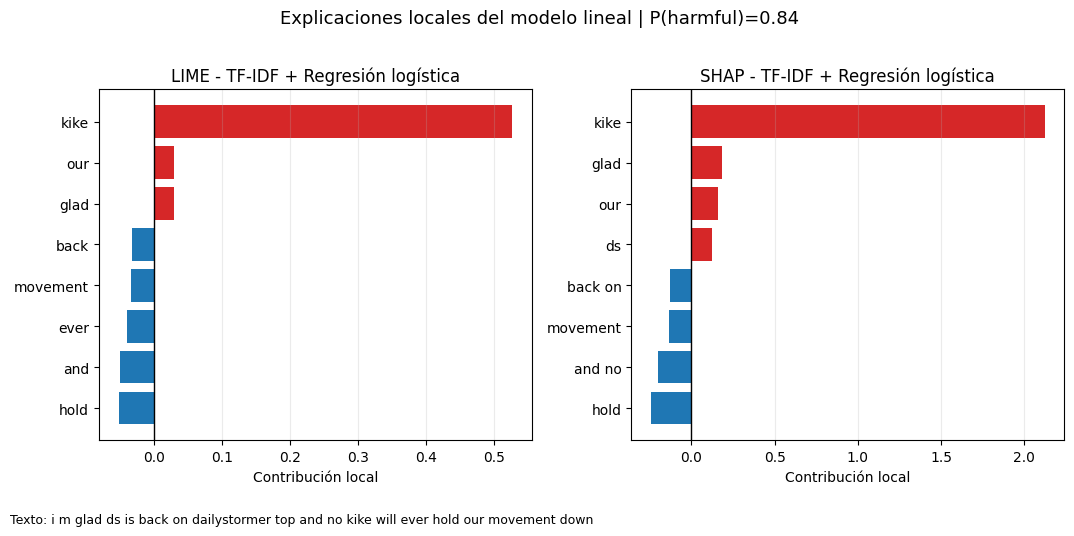

In [31]:
# Ejemplo visual con LIME y SHAP en el modelo lineal (HateXplain)
linear_example = hx_examples[hx_examples["label"] == 1].iloc[-1]
linear_text = linear_example["text"]
linear_prob = float(predict_proba_logreg("hatexplain", [linear_text])[0, 1])

linear_lime_pairs, _ = explain_with_lime(
    linear_text,
    predict_fn=lambda xs: predict_proba_logreg("hatexplain", xs),
    class_names=get_label_names("hatexplain"),
    num_features=10,
    positive_class=1,
)
linear_shap_pairs = explain_with_shap_linear(
    linear_text,
    pipeline=logreg_models["hatexplain"],
    shap_explainer=shap_explainers_logreg["hatexplain"],
    top_k=10,
)
linear_coef_pairs = local_linear_contributions(linear_text, logreg_models["hatexplain"], top_k=10)

print("Ejemplo visualizado (modelo lineal):", linear_text)
print("Rationale humana:", linear_example.get("rationale_tokens", []))
print("Probabilidad harmful:", round(linear_prob, 3))
print("LIME:", linear_lime_pairs[:8])
print("SHAP:", linear_shap_pairs[:8])
print("Coef*x:", linear_coef_pairs[:8])

plot_local_explanation_grid(
    text=linear_text,
    explanations={
        "LIME - TF-IDF + Regresión logística": linear_lime_pairs,
        "SHAP - TF-IDF + Regresión logística": linear_shap_pairs,
    },
    title=f"Explicaciones locales del modelo lineal | P(harmful)={linear_prob:.2f}",
    top_k=8,
)


Ejemplo visualizado (transformer): i m glad ds is back on dailystormer top and no kike will ever hold our movement down
Rationale humana: ['kike']
Probabilidad harmful: 0.991
LIME-transformer: [('kike', 0.8547598579247037), ('i', 0.011424979506859037), ('dailystormer', -0.00941023531191907), ('glad', 0.00790156202555642), ('movement', -0.007302778355741628), ('and', -0.006998620127654349), ('on', -0.006903187127204887), ('down', 0.006639777000889599)]
Integrated Gradients: [('kike', 0.6703079491853714), ('glad', 0.0458131842315197), ('movement', -0.031296610832214355), ('dailystormer', -0.029856291599571705), ('down', 0.028405386954545975), ('our', 0.024338925257325172), ('ever', -0.020633354783058167), ('no', -0.020198479294776917)]
Predicción IG: 1 | delta: -0.045215


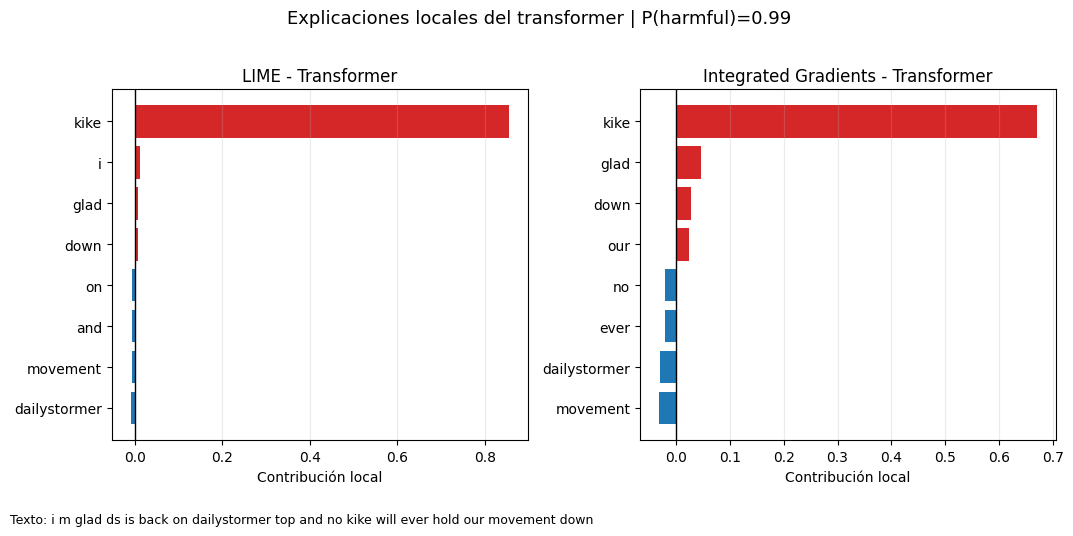

In [32]:
# Ejemplo visual con LIME e Integrated Gradients en el transformer (HateXplain)
transformer_example = hx_examples[hx_examples["label"] == 1].iloc[-1]
transformer_text = transformer_example["text"]
transformer_prob = float(predict_proba_transformer(transformer_models["hatexplain"], [transformer_text])[0, 1])

transformer_lime_pairs, _ = explain_with_lime(
    transformer_text,
    predict_fn=lambda xs: predict_proba_transformer(transformer_models["hatexplain"], xs),
    class_names=get_label_names("hatexplain"),
    num_features=10,
    positive_class=1,
)
transformer_ig_pairs, transformer_pred_label, transformer_delta = explain_with_integrated_gradients(
    transformer_text,
    trainer=transformer_models["hatexplain"],
    target_label=None,
    n_steps=32,
)

print("Ejemplo visualizado (transformer):", transformer_text)
print("Rationale humana:", transformer_example.get("rationale_tokens", []))
print("Probabilidad harmful:", round(transformer_prob, 3))
print("LIME-transformer:", transformer_lime_pairs[:8])
print("Integrated Gradients:", transformer_ig_pairs[:8])
print("Predicción IG:", transformer_pred_label, "| delta:", round(transformer_delta, 6))

plot_local_explanation_grid(
    text=transformer_text,
    explanations={
        "LIME - Transformer": transformer_lime_pairs,
        "Integrated Gradients - Transformer": transformer_ig_pairs,
    },
    title=f"Explicaciones locales del transformer | P(harmful)={transformer_prob:.2f}",
    top_k=8,
)


### De los ejemplos

Los gráficos permiten ver de forma más directa qué señales usa cada explicador. En los ejemplos positivos, los métodos suele destacar palabras ofensivas o asociadas a ataques identitarios, aunque no siempre con la misma intensidad ni con el mismo signo.

En el modelo lineal, SHAP es bastante coherente con los pesos internos del clasificador porque ambos trabajan sobre la representación TF-IDF. En el transformer, LIME e Integrated Gradients pueden coincidir en el token principal, pero divergen en tokens secundarios. Esta diferencia es relevante: una explicación local no debe interpretarse como una verdad única, sino como una aproximación dependiente del método.

En los ejemplos negativos con vocabulario sensible, este tipo de visualización también ayuda a detectar si el modelo está reaccionando a una palabra identitaria aislada o al contexto completo de la frase. Esto es especialmente importante en moderación, porque muchos textos mencionan identidades de forma legítima, informativa o incluso para denunciar abusos.


## 8. Métricas de comparación entre explicadores

Se miden tres familias de comparación:

1. **Solapamiento top-k**  
   Mide qué proporción de tokens relevantes coincide entre dos métodos. Se usa Jaccard sobre los tokens más importantes.

2. **Correlación de rankings**  
   Mide si los métodos ordenan de forma parecida los tokens compartidos. Se usa Spearman sobre los tokens comunes.

3. **Alineación con rationale humana (HateXplain)**  
   Mide qué parte de los tokens marcados por anotadores humanos aparece entre los tokens destacados por el explicador.

Los rationales humanos se usan como **proxy de plausibilidad**, no como verdad causal absoluta. Una explicación puede coincidir con humanos y aun así no ser causal; también puede no coincidir con humanos porque el modelo usa señales estadísticas distintas.


In [33]:

def normalize_token(tok: str) -> str:
    tok = tok.lower().strip()
    tok = re.sub(r"^[^\w@#]+|[^\w@#]+$", "", tok)
    return tok

def clean_pairs(pairs):
    out = []
    for tok, score in pairs:
        tok_n = normalize_token(tok)
        if tok_n:
            out.append((tok_n, float(score)))
    return out

def top_k_tokens(pairs, k: int = 5, positive_only: bool = False):
    pairs = clean_pairs(pairs)
    if positive_only:
        pairs = [p for p in pairs if p[1] > 0]
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)
    return [tok for tok, _ in pairs[:k]]

def jaccard_top_k(pairs_a, pairs_b, k: int = 5, positive_only: bool = False):
    a = set(top_k_tokens(pairs_a, k=k, positive_only=positive_only))
    b = set(top_k_tokens(pairs_b, k=k, positive_only=positive_only))
    if len(a | b) == 0:
        return np.nan
    return len(a & b) / len(a | b)

def rationale_recall_at_k(pairs, rationale_tokens, k: int = 5):
    expl = set(top_k_tokens(pairs, k=k))
    human = set(normalize_token(t) for t in rationale_tokens if normalize_token(t))
    if len(human) == 0:
        return np.nan
    return len(expl & human) / len(human)

def pairs_to_rank_dict(pairs, top_k: int = 20):
    pairs = clean_pairs(pairs)
    pairs = sorted(pairs, key=lambda x: abs(x[1]), reverse=True)[:top_k]
    return {tok: rank for rank, (tok, _) in enumerate(pairs, start=1)}

def spearman_on_shared_top_tokens(pairs_a, pairs_b, top_k: int = 20):
    from scipy.stats import spearmanr
    ra = pairs_to_rank_dict(pairs_a, top_k=top_k)
    rb = pairs_to_rank_dict(pairs_b, top_k=top_k)
    shared = sorted(set(ra) & set(rb))
    if len(shared) < 3:
        return np.nan
    va = [ra[t] for t in shared]
    vb = [rb[t] for t in shared]
    return float(spearmanr(va, vb).correlation)

In [34]:

def evaluate_explanations_hatexplain_classic(df: pd.DataFrame, sample_size: int = 50):
    sample = choose_balanced_examples(
        df,
        n_per_class=max(1, sample_size // 2),
        seed=CFG.seed
    )

    rows = []
    for _, row in sample.iterrows():
        text = row["text"]
        rationale = row["rationale_tokens"]

        lime_pairs, _ = explain_with_lime(
            text,
            predict_fn=lambda xs: predict_proba_logreg("hatexplain", xs),
            class_names=get_label_names("hatexplain"),
            num_features=10,
            positive_class=1,
        )
        shap_pairs = explain_with_shap_linear(
            text,
            logreg_models["hatexplain"],
            shap_explainers_logreg["hatexplain"],
            top_k=10,
        )
        coef_pairs = local_linear_contributions(text, logreg_models["hatexplain"], top_k=10)

        rows.append({
            "id": row["id"],
            "label": row["label"],
            "jaccard_lime_shap@5": jaccard_top_k(lime_pairs, shap_pairs, k=5),
            "jaccard_lime_coef@5": jaccard_top_k(lime_pairs, coef_pairs, k=5),
            "jaccard_shap_coef@5": jaccard_top_k(shap_pairs, coef_pairs, k=5),
            "spearman_lime_shap": spearman_on_shared_top_tokens(lime_pairs, shap_pairs, top_k=10),
            "rationale_recall_lime@5": rationale_recall_at_k(lime_pairs, rationale, k=5),
            "rationale_recall_shap@5": rationale_recall_at_k(shap_pairs, rationale, k=5),
            "rationale_recall_coef@5": rationale_recall_at_k(coef_pairs, rationale, k=5),
        })

    return pd.DataFrame(rows)

classic_hx_exp_eval = evaluate_explanations_hatexplain_classic(
    hx_test.sample(min(len(hx_test), CFG.explanation_sample_size), random_state=CFG.seed),
    sample_size=min(CFG.explanation_sample_size, len(hx_test))
)
classic_hx_exp_eval.describe().T

,count,mean,std,min,25%,50%,75%,max
label,53.0,0.566038,0.500363,0.000000,0.000000,1.000000,1.000000,1.0
jaccard_lime_shap@5,53.0,0.449970,0.201109,0.111111,0.250000,0.428571,0.666667,1.0
jaccard_lime_coef@5,53.0,0.477149,0.219398,0.111111,0.250000,0.428571,0.666667,1.0
jaccard_shap_coef@5,53.0,0.911950,0.148366,0.666667,0.666667,1.000000,1.000000,1.0
spearman_lime_shap,51.0,0.725677,0.253373,-0.100000,0.603571,0.800000,0.914286,1.0
rationale_recall_lime@5,30.0,0.494835,0.326523,0.105263,0.190972,0.464286,0.702381,1.0
rationale_recall_shap@5,30.0,0.443446,0.328408,0.090909,0.157115,0.333333,0.642857,1.0
rationale_recall_coef@5,30.0,0.435990,0.329218,0.090909,0.157115,0.333333,0.642857,1.0


In [35]:

def evaluate_explanations_hatexplain_transformer(df: pd.DataFrame, sample_size: int = 30):
    sample = choose_balanced_examples(
        df,
        n_per_class=max(1, sample_size // 2),
        seed=CFG.seed
    )

    rows = []
    for _, row in sample.iterrows():
        text = row["text"]
        rationale = row["rationale_tokens"]

        lime_pairs, _ = explain_with_lime(
            text,
            predict_fn=lambda xs: predict_proba_transformer(transformer_models["hatexplain"], xs),
            class_names=get_label_names("hatexplain"),
            num_features=10,
            positive_class=1,
        )
        ig_pairs, _, _ = explain_with_integrated_gradients(
            text,
            trainer=transformer_models["hatexplain"],
            target_label=None,
            n_steps=32,
        )

        rows.append({
            "id": row["id"],
            "label": row["label"],
            "jaccard_lime_ig@5": jaccard_top_k(lime_pairs, ig_pairs, k=5),
            "spearman_lime_ig": spearman_on_shared_top_tokens(lime_pairs, ig_pairs, top_k=10),
            "rationale_recall_lime@5": rationale_recall_at_k(lime_pairs, rationale, k=5),
            "rationale_recall_ig@5": rationale_recall_at_k(ig_pairs, rationale, k=5),
        })

    return pd.DataFrame(rows)

transformer_hx_exp_eval = evaluate_explanations_hatexplain_transformer(
    hx_test.sample(min(len(hx_test), CFG.explanation_sample_size), random_state=CFG.seed),
    sample_size=min(30, len(hx_test))
)
transformer_hx_exp_eval.describe().T

,count,mean,std,min,25%,50%,75%,max
label,30.0,0.500000,0.508548,0.000000,0.000000,0.500000,1.000000,1.0
jaccard_lime_ig@5,30.0,0.419656,0.230553,0.000000,0.250000,0.428571,0.666667,1.0
spearman_lime_ig,29.0,0.390655,0.381270,-0.400000,0.000000,0.371429,0.716667,1.0
rationale_recall_lime@5,15.0,0.602227,0.310783,0.125000,0.324675,0.666667,0.833333,1.0
rationale_recall_ig@5,15.0,0.596551,0.328625,0.173913,0.309524,0.500000,1.000000,1.0


### Comparación entre explicadores

En el modelo lineal, SHAP coincide bastante con los pesos aprendidos por la regresión logística porque el modelo toma sus decisiones a partir de palabras representadas con TF-IDF y si una palabra tiene mucho peso en el modelo, también debería aparecer como importante en la explicación.

En el transformer ocurre algo distinto, en LIME e Integrated Gradients no siempre destacan las mismas palabras. Este resultado es importante porque muestra que una explicación no es una verdad absoluta, sino una aproximación que depende del método utilizado.


## 9. Robustez y estabilidad de explicaciones

Una explicación útil debería ser relativamente estable cuando el significado del texto apenas cambia. Por eso se prueban tres perturbaciones simples:

- eliminación de una palabra funcional;
- introducción de una errata leve;
- sustitución de una palabra por un sinónimo simple o variante cercana.

In [36]:

STOPWORDS_EN_ES = {
    "the", "a", "an", "and", "or", "to", "of", "in", "on", "for", "with", "at", "by",
    "i", "you", "he", "she", "it", "we", "they",
    "el", "la", "los", "las", "un", "una", "y", "o", "de", "en", "con", "por", "para", "que"
}

SYNONYM_MAP = {
    "woman": "lady",
    "women": "ladies",
    "man": "male",
    "girl": "young woman",
    "hate": "dislike",
    "stupid": "dumb",
    "idiot": "fool",
    "good": "nice",
    "bad": "awful",
}

def remove_random_stopword(text: str, seed: int = 99) -> str:
    toks = text.split()
    idxs = [i for i, tok in enumerate(toks) if normalize_token(tok) in STOPWORDS_EN_ES]
    if not idxs:
        return text
    rng = random.Random(seed)
    i = rng.choice(idxs)
    return " ".join(toks[:i] + toks[i+1:])

def inject_small_typo(text: str, seed: int = 99) -> str:
    toks = text.split()
    rng = random.Random(seed)
    candidate_idxs = [i for i, tok in enumerate(toks) if len(normalize_token(tok)) >= 4]
    if not candidate_idxs:
        return text
    i = rng.choice(candidate_idxs)
    tok = toks[i]
    j = max(1, len(tok) // 2)
    if j < len(tok):
        tok = tok[:j] + tok[j+1] + tok[j] + tok[j+2:] if j + 1 < len(tok) else tok
    toks[i] = tok
    return " ".join(toks)

def replace_simple_synonym(text: str, seed: int = 99) -> str:
    toks = text.split()
    replaced = False
    new_toks = []
    for tok in toks:
        key = normalize_token(tok)
        if not replaced and key in SYNONYM_MAP:
            new_toks.append(SYNONYM_MAP[key])
            replaced = True
        else:
            new_toks.append(tok)
    return " ".join(new_toks)

def build_perturbations(text: str, seed: int = 99) -> dict:
    return {
        "drop_stopword": remove_random_stopword(text, seed=seed),
        "small_typo": inject_small_typo(text, seed=seed),
        "simple_synonym": replace_simple_synonym(text, seed=seed),
    }

In [37]:

def prediction_shift(prob_a, prob_b):
    return abs(float(prob_a) - float(prob_b))

def evaluate_stability_for_instance(text, explain_fn_a, predict_fn, k=5):
    original_pairs = explain_fn_a(text)
    original_prob = float(predict_fn([text])[0, 1])

    rows = []
    for name, pert_text in build_perturbations(text, seed=CFG.seed).items():
        pert_pairs = explain_fn_a(pert_text)
        pert_prob = float(predict_fn([pert_text])[0, 1])

        rows.append({
            "perturbation": name,
            "prob_shift": prediction_shift(original_prob, pert_prob),
            "topk_jaccard": jaccard_top_k(original_pairs, pert_pairs, k=k),
        })
    return pd.DataFrame(rows)

def benchmark_stability_logreg_hx(df, n=20):
    sample = choose_balanced_examples(df, n_per_class=max(1, n // 2), seed=CFG.seed)
    rows = []
    for _, row in sample.iterrows():
        text = row["text"]

        lime_fn = lambda t: explain_with_lime(
            t,
            predict_fn=lambda xs: predict_proba_logreg("hatexplain", xs),
            class_names=get_label_names("hatexplain"),
            num_features=10,
            positive_class=1,
        )[0]
        shap_fn = lambda t: explain_with_shap_linear(
            t,
            logreg_models["hatexplain"],
            shap_explainers_logreg["hatexplain"],
            top_k=10,
        )

        for method_name, fn in [("lime", lime_fn), ("shap", shap_fn)]:
            stab = evaluate_stability_for_instance(
                text=text,
                explain_fn_a=fn,
                predict_fn=lambda xs: predict_proba_logreg("hatexplain", xs),
                k=5,
            )
            stab["method"] = method_name
            stab["id"] = row["id"]
            rows.append(stab)
    return pd.concat(rows, ignore_index=True)

stability_logreg_hx = benchmark_stability_logreg_hx(
    hx_test.sample(min(len(hx_test), CFG.robustness_sample_size), random_state=CFG.seed),
    n=min(CFG.robustness_sample_size, len(hx_test))
)
stability_logreg_hx.groupby(["method", "perturbation"])[["prob_shift", "topk_jaccard"]].mean()

prob_shift  topk_jaccard
method perturbation                            
lime   drop_stopword     0.016358      0.868734
       simple_synonym    0.011714      0.860276
       small_typo        0.037586      0.790100
shap   drop_stopword     0.016358      0.932331
       simple_synonym    0.011714      0.929825
       small_typo        0.037586      0.851504

In [38]:
def benchmark_stability_transformer_hx(df, n=20):
    sample = choose_balanced_examples(df, n_per_class=max(1, n // 2), seed=CFG.seed)
    rows = []
    for _, row in sample.iterrows():
        text = row["text"]

        lime_fn = lambda t: explain_with_lime(
            t,
            predict_fn=lambda xs: predict_proba_transformer(transformer_models["hatexplain"], xs),
            class_names=get_label_names("hatexplain"),
            num_features=10,
            positive_class=1,
        )[0]
        ig_fn = lambda t: explain_with_integrated_gradients(
            t,
            trainer=transformer_models["hatexplain"],
            target_label=None,
            n_steps=32,
        )[0]

        for method_name, fn in [("lime_transformer", lime_fn), ("integrated_gradients", ig_fn)]:
            stab = evaluate_stability_for_instance(
                text=text,
                explain_fn_a=fn,
                predict_fn=lambda xs: predict_proba_transformer(transformer_models["hatexplain"], xs),
                k=5,
            )
            stab["method"] = method_name
            stab["id"] = row["id"]
            rows.append(stab)
    return pd.concat(rows, ignore_index=True)

stability_transformer_hx = benchmark_stability_transformer_hx(
    hx_test.sample(min(len(hx_test), CFG.robustness_sample_size), random_state=CFG.seed),
    n=min(20, len(hx_test))
)
stability_transformer_hx.groupby(["method", "perturbation"])[["prob_shift", "topk_jaccard"]].mean()

prob_shift  topk_jaccard
method               perturbation                            
integrated_gradients drop_stopword     0.033936      0.733214
                     simple_synonym    0.004931      0.963333
                     small_typo        0.054269      0.635833
lime_transformer     drop_stopword     0.033936      0.800000
                     simple_synonym    0.004931      0.888095
                     small_typo        0.054269      0.619643

### Interpretación de robustez

La perturbación que más afecta a las explicaciones es la **errata leve**. Esto tiene sentido: aunque el cambio parezca pequeño para una persona, para el modelo puede alterar la forma en que el texto se divide en tokens o hacer que una palabra importante deje de reconocerse correctamente.

En cambio, eliminar una palabra poco informativa o cambiar una palabra sencilla por un sinónimo suele modificar menos el significado del texto por eso, en esos casos las explicaciones cambian menos.

También se observa que el modelo clásico mantiene explicaciones más estables eso quiere decir que el transformer entiende mejor el contexto, pero sus explicaciones pueden ser más sensibles a pequeños cambios en la entrada.

## 10. Auditoría de sesgos y atajos léxicos: *Identity Swap Audit*

### Diseño

1. Se crea un conjunto pequeño de plantillas neutrales.
2. Se sustituyen términos de identidad relacionados con género, origen, religión y orientación.
3. Se compara:
   - la probabilidad predicha de clase positiva;
   - si el propio término identitario aparece entre los tokens más influyentes;
   - si el patrón se repite entre modelos y explicadores.

La auditoría no demuestra discriminación por sí sola, pero sí sirve como una prueba exploratoria de **atajos léxicos**. Si un modelo destaca repetidamente palabras como `muslim`, `gay`, `immigrant` o `woman` en frases neutrales, conviene revisar los datos, las etiquetas y el uso previsto del sistema.


In [39]:

IDENTITY_TERMS = {
    "gender": ["woman", "man", "girl", "boy"],
    "origin": ["immigrant", "citizen", "foreigner", "local"],
    "religion": ["muslim", "christian", "jewish person", "atheist"],
    "orientation": ["gay person", "straight person", "lesbian woman", "heterosexual man"],
}

NEUTRAL_TEMPLATES = [
    "I spoke with a {term} colleague after work.",
    "The {term} student asked a question in class.",
    "My neighbor is a {term}.",
    "A {term} person joined the discussion yesterday.",
    "We hired a {term} engineer for the project.",
]

def build_identity_audit_frame():
    rows = []
    for dim, terms in IDENTITY_TERMS.items():
        for template in NEUTRAL_TEMPLATES:
            for term in terms:
                rows.append({
                    "dimension": dim,
                    "term": term,
                    "text": template.format(term=term),
                })
    return pd.DataFrame(rows)

identity_audit_df = build_identity_audit_frame()
identity_audit_df.head()

,dimension,term,text
0,gender,woman,I spoke with a woman colleague after work.
1,gender,man,I spoke with a man colleague after work.
2,gender,girl,I spoke with a girl colleague after work.
3,gender,boy,I spoke with a boy colleague after work.
4,gender,woman,The woman student asked a question in class.


In [40]:

def top_contains_term(pairs, term, k=5):
    toks = top_k_tokens(pairs, k=k)
    term_norm = normalize_token(term)
    term_parts = {normalize_token(p) for p in term.split()}
    return int(term_norm in toks or len(term_parts & set(toks)) > 0)

def audit_identity_sensitivity_logreg(dataset_name: str, df_pairs: pd.DataFrame):
    rows = []
    for _, row in df_pairs.iterrows():
        text = row["text"]
        prob = float(predict_proba_logreg(dataset_name, [text])[0, 1])
        lime_pairs, _ = explain_with_lime(
            text,
            predict_fn=lambda xs: predict_proba_logreg(dataset_name, xs),
            class_names=get_label_names(dataset_name),
            num_features=10,
            positive_class=1,
        )
        shap_pairs = explain_with_shap_linear(
            text,
            logreg_models[dataset_name],
            shap_explainers_logreg[dataset_name],
            top_k=10,
        )
        rows.append({
            **row.to_dict(),
            "dataset": dataset_name,
            "prob_pos": prob,
            "lime_identity_in_top5": top_contains_term(lime_pairs, row["term"], k=5),
            "shap_identity_in_top5": top_contains_term(shap_pairs, row["term"], k=5),
        })
    return pd.DataFrame(rows)

identity_audit_logreg_hx = audit_identity_sensitivity_logreg("hatexplain", identity_audit_df)
identity_audit_logreg_edos = audit_identity_sensitivity_logreg("edos", identity_audit_df)

display(identity_audit_logreg_hx.groupby("dimension")[["prob_pos", "lime_identity_in_top5", "shap_identity_in_top5"]].mean())
display(identity_audit_logreg_edos.groupby("dimension")[["prob_pos", "lime_identity_in_top5", "shap_identity_in_top5"]].mean())

,prob_pos,lime_identity_in_top5,shap_identity_in_top5
dimension,,,
gender,0.337104,0.90,0.75
orientation,0.275679,1.00,1.00
origin,0.277809,0.75,0.65
religion,0.295594,0.95,1.00


,prob_pos,lime_identity_in_top5,shap_identity_in_top5
dimension,,,
gender,0.171486,0.85,0.85
orientation,0.118026,1.00,1.00
origin,0.074738,0.60,0.55
religion,0.061415,0.85,0.85


In [41]:

def audit_identity_sensitivity_transformer_hx(df_pairs: pd.DataFrame):
    rows = []
    for _, row in df_pairs.iterrows():
        text = row["text"]
        prob = float(predict_proba_transformer(transformer_models["hatexplain"], [text])[0, 1])

        lime_pairs, _ = explain_with_lime(
            text,
            predict_fn=lambda xs: predict_proba_transformer(transformer_models["hatexplain"], xs),
            class_names=get_label_names("hatexplain"),
            num_features=10,
            positive_class=1,
        )
        ig_pairs, _, _ = explain_with_integrated_gradients(
            text,
            trainer=transformer_models["hatexplain"],
            target_label=None,
            n_steps=32,
        )

        rows.append({
            **row.to_dict(),
            "dataset": "hatexplain",
            "prob_pos": prob,
            "lime_identity_in_top5": top_contains_term(lime_pairs, row["term"], k=5),
            "ig_identity_in_top5": top_contains_term(ig_pairs, row["term"], k=5),
        })
    return pd.DataFrame(rows)

identity_audit_transformer_hx = audit_identity_sensitivity_transformer_hx(identity_audit_df)
identity_audit_transformer_hx.groupby("dimension")[["prob_pos", "lime_identity_in_top5", "ig_identity_in_top5"]].mean()

,prob_pos,lime_identity_in_top5,ig_identity_in_top5
dimension,,,
gender,0.127677,0.40,0.85
orientation,0.208891,1.00,0.95
origin,0.147037,0.75,0.85
religion,0.160400,0.70,0.75


### Interpretación de la auditoría de identidad

El resultado más importante no es solo la probabilidad media, sino la frecuencia con la que el término identitario aparece entre las señales más influyentes. En frases neutrales, lo deseable sería que palabras como `woman`, `muslim`, `immigrant` o `gay person` no dominaran la explicación salvo que el contexto textual justificara esa relevancia.

La auditoría muestra un posible patrón de dependencia léxica. Esto no significa que el modelo sea necesariamente injusto en todos los casos, pero sí que su uso en moderación requeriría pruebas adicionales: evaluación por subgrupos, análisis de falsos positivos, revisión de plantillas más variadas y supervisión humana.


## 12. Traducción de explicaciones a lenguaje natural para moderación

Este bloque transforma una explicación local en un mensaje breve para moderación. La intención no es automatizar una justificación moral, sino producir una ayuda de lectura: qué pistas empujan la predicción hacia la clase positiva, qué elementos la contrarrestan y qué advertencias debe recordar el usuario.


i m glad ds is back on dailystormer top and no kike will ever hold our movement down


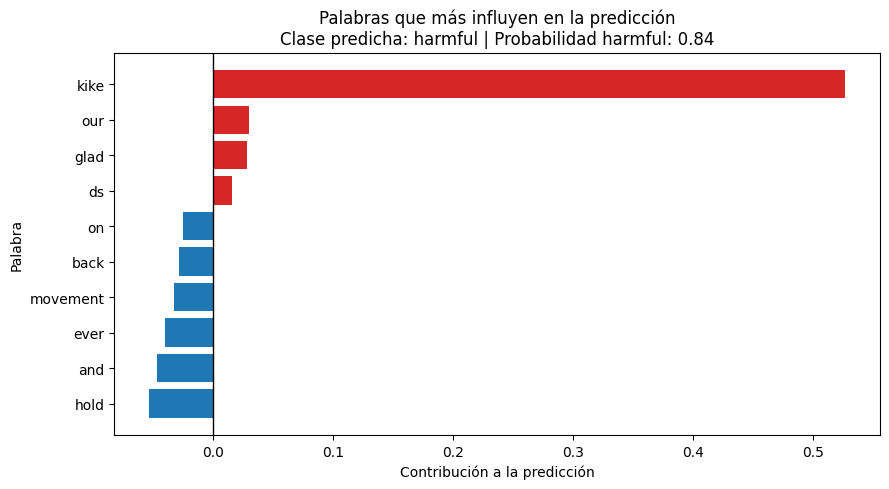

In [42]:
def plot_word_contributions(
    text: str,
    prob_pos: float,
    predicted_label: str,
    pairs: list[tuple[str, float]],
    top_k: int = 10
):
    # Limpiamos y ordenamos por importancia absoluta
    pairs = sorted(clean_pairs(pairs), key=lambda x: abs(x[1]), reverse=True)
    top = pairs[:top_k]

    contrib_df = pd.DataFrame(top, columns=["token", "contribucion"])
    contrib_df = contrib_df.sort_values("contribucion")

    colors = [
        "tab:red" if value > 0 else "tab:blue"
        for value in contrib_df["contribucion"]
    ]

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.barh(
        contrib_df["token"],
        contrib_df["contribucion"],
        color=colors
    )

    ax.axvline(0, color="black", linewidth=1)

    ax.set_title(
        f"Palabras que más influyen en la predicción\n"
        f"Clase predicha: {predicted_label} | Probabilidad harmful: {prob_pos:.2f}"
    )

    ax.set_xlabel("Contribución a la predicción")
    ax.set_ylabel("Palabra")

    plt.tight_layout()
    plt.show()

sample_text = hx_examples.iloc[3]["text"]

sample_prob = float(
    predict_proba_logreg("hatexplain", [sample_text])[0, 1]
)

sample_pairs, _ = explain_with_lime(
    sample_text,
    predict_fn=lambda xs: predict_proba_logreg("hatexplain", xs),
    class_names=get_label_names("hatexplain"),
    num_features=10,
    positive_class=1,
)
print(sample_text)
plot_word_contributions(
    text=sample_text,
    prob_pos=sample_prob,
    predicted_label="harmful",
    pairs=sample_pairs,
    top_k=10
)

The word "kike" is a highly offensive ethnic slur used as an insulting and derogatory term for a Jewish person. It is widely classified as hate.
Se puede ver claramente que ha clasificado correctamente la frase para las palabras que influyen en la predicción.

In [43]:
# Exportación opcional de resultados tabulares para la carpeta resultados

Path("resultados").mkdir(exist_ok=True)

all_metrics_df.to_csv("resultados/metricas_modelos.csv", index=False)
classic_hx_exp_eval.to_csv("resultados/comparacion_explicadores_modelo_lineal.csv", index=False)
transformer_hx_exp_eval.to_csv("resultados/comparacion_explicadores_transformer.csv", index=False)
stability_logreg_hx.to_csv("resultados/robustez_modelo_lineal.csv", index=False)
stability_transformer_hx.to_csv("resultados/robustez_transformer.csv", index=False)
identity_audit_logreg_hx.to_csv("resultados/auditoria_identidad_logreg_hatexplain.csv", index=False)
identity_audit_logreg_edos.to_csv("resultados/auditoria_identidad_logreg_edos.csv", index=False)
identity_audit_transformer_hx.to_csv("resultados/auditoria_identidad_transformer_hatexplain.csv", index=False)

print("Resultados exportados en ./resultados/")


Resultados exportados en ./resultados/


## 11. Conclusiones

El objetivo de este proyecto no era solo entrenar un detector de lenguaje tóxico, sino analizar si sus explicaciones son realmente útiles y fiables. Para ello se compararon modelos clásicos y modelos basados en transformers, junto con distintos métodos de explicabilidad como LIME, SHAP e Integrated Gradients.

Los resultados muestran que el transformer obtiene mejores métricas que el modelo clásico, especialmente en EDOS. Sin embargo, esta mejora no significa automáticamente que sea la mejor opción en todos los casos. El modelo clásico basado en TF-IDF y Regresión Logística es más sencillo, más rápido y más fácil de interpretar. En cambio, el transformer ofrece mejor rendimiento, pero sus explicaciones son más costosas y menos estables.

Una conclusión importante es que no todos los explicadores muestran exactamente lo mismo. En el modelo lineal, las explicaciones son más coherentes porque el modelo depende directamente de palabras y pesos aprendidos. En el transformer, LIME e Integrated Gradients no siempre destacan las mismas palabras. Esto indica que una explicación no debe interpretarse como una verdad absoluta, sino como una aproximación que depende del método utilizado.

El análisis de robustez también muestra que pequeñas erratas pueden cambiar las explicaciones, sobre todo en el transformer. Esto es relevante porque en redes sociales los textos suelen contener abreviaturas, errores ortográficos, ironía o expresiones informales. Por tanto, un sistema de moderación automática debe ser evaluado no solo con textos limpios, sino también con ejemplos realistas.

La auditoría de identidad detecta otro punto importante: algunos términos relacionados con género, religión, origen u orientación pueden aparecer como influyentes incluso en frases neutrales. Esto no demuestra por sí solo que el modelo sea discriminatorio, pero sí muestra un posible riesgo de atajos léxicos. En un contexto real, este tipo de comportamiento debería revisarse cuidadosamente para evitar falsos positivos contra determinados colectivos.

En conclusión, las técnicas XAI son útiles para entender mejor los modelos de detección de toxicidad, pero no deben usarse como una justificación automática de las decisiones del sistema. Su valor principal está en la auditoría: permiten comparar explicadores, detectar inestabilidad, revisar posibles sesgos y entender mejor qué señales está usando el modelo. Para tareas sensibles como la moderación de contenido, la explicación debe servir como apoyo a la revisión humana, no como sustituto de ella.

YHJ2026

## Referencias

### Datasets 

- Mathew, B., Saha, P., Yimam, S. M., Biemann, C., Goyal, P., & Mukherjee, A. (2021). **HateXplain: A Benchmark Dataset for Explainable Hate Speech Detection**. *Proceedings of the AAAI Conference on Artificial Intelligence*, 35(17), 14867–14875. https://doi.org/10.1609/aaai.v35i17.17745
- Kirk, H. R., Yin, W., Vidgen, B., & Röttger, P. (2023). **SemEval-2023 Task 10: Explainable Detection of Online Sexism**. *Proceedings of the 17th International Workshop on Semantic Evaluation (SemEval-2023)*. https://aclanthology.org/2023.semeval-1.305/
- Rewire. (2023). **EDOS: Explainable Detection of Online Sexism — Public repository for SemEval 2023 Task 10**. https://github.com/rewire-online/edos

### Métodos XAI

- Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). **“Why Should I Trust You?”: Explaining the Predictions of Any Classifier**. *Proceedings of NAACL-HLT 2016: Demonstrations*, 97–101. https://doi.org/10.18653/v1/N16-3020
- Lundberg, S. M., & Lee, S.-I. (2017). **A Unified Approach to Interpreting Model Predictions**. *Advances in Neural Information Processing Systems*, 30. https://arxiv.org/abs/1705.07874
- Sundararajan, M., Taly, A., & Yan, Q. (2017). **Axiomatic Attribution for Deep Networks**. *Proceedings of the 34th International Conference on Machine Learning*, 3319–3328. https://proceedings.mlr.press/v70/sundararajan17a.html
- Molnar, C. (2022). **Interpretable Machine Learning: A Guide for Making Black Box Models Explainable**. https://christophm.github.io/interpretable-ml-book/

### Modelos y librerías

- Devlin, J., Chang, M.-W., Lee, K., & Toutanova, K. (2019). **BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding**. *Proceedings of NAACL-HLT 2019*, 4171–4186. https://aclanthology.org/N19-1423/
- Sanh, V., Debut, L., Chaumond, J., & Wolf, T. (2019). **DistilBERT, a distilled version of BERT: smaller, faster, cheaper and lighter**. https://arxiv.org/abs/1910.01108
- Wolf, T., Debut, L., Sanh, V., Chaumond, J., Delangue, C., Moi, A., Cistac, P., Rault, T., Louf, R., Funtowicz, M., Davison, J., Shleifer, S., von Platen, P., Ma, C., Jernite, Y., Plu, J., Xu, C., Le Scao, T., Gugger, S., Drame, M., Lhoest, Q., & Rush, A. M. (2020). **Transformers: State-of-the-Art Natural Language Processing**. *Proceedings of EMNLP 2020: System Demonstrations*, 38–45. https://aclanthology.org/2020.emnlp-demos.6/
- Lhoest, Q., del Moral, A. V., Jernite, Y., Thakur, A., von Platen, P., Patil, S., Chaumond, J., Drame, M., Plu, J., Tunstall, L., Davison, J., Šaško, M., Chhablani, G., Malik, B., Brandeis, S., Le Scao, T., Sanh, V., Xu, C., Patry, N., McMillan-Major, A., Schmid, P., Gugger, S., Delangue, C., Matussière, T., Debut, L., Bekman, S., Cistac, P., Goehringer, T., Mustar, V., Lagunas, F., Rush, A. M., & Wolf, T. (2021). **Datasets: A Community Library for Natural Language Processing**. *Proceedings of EMNLP 2021: System Demonstrations*, 175–184. https://aclanthology.org/2021.emnlp-demo.21/
- Kokhlikyan, N., Miglani, V., Martin, M., Wang, E., Alsallakh, B., Reynolds, J., Melnikov, A., Kliushkina, N., Araya, C., Yan, S., & Reblitz-Richardson, O. (2020). **Captum: A unified and generic model interpretability library for PyTorch**. https://arxiv.org/abs/2009.07896
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., VanderPlas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). **Scikit-learn: Machine Learning in Python**. *Journal of Machine Learning Research*, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html
- Hugging Face. **distilbert-base-multilingual-cased model card**. https://huggingface.co/distilbert/distilbert-base-multilingual-cased

### Fairness y auditoría de sesgos

- Bellamy, R. K. E., Dey, K., Hind, M., Hoffman, S. C., Houde, S., Kannan, K., Lohia, P., Martino, J., Mehta, S., Mojsilović, A., Nagar, S., Ramamurthy, K. N., Richards, J., Saha, D., Sattigeri, P., Singh, M., Varshney, K. R., & Zhang, Y. (2018). **AI Fairness 360: An Extensible Toolkit for Detecting, Understanding, and Mitigating Unwanted Algorithmic Bias**. https://arxiv.org/abs/1810.01943
- Mehrabi, N., Morstatter, F., Saxena, N., Lerman, K., & Galstyan, A. (2021). **A Survey on Bias and Fairness in Machine Learning**. *ACM Computing Surveys*, 54(6), 1–35. https://doi.org/10.1145/3457607
